<a href="https://colab.research.google.com/github/alperyldzzz/Lab/blob/main/Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB 5
=====

PART 1: Newton Method Dependence on Initial Guess
------------------------------------------------
Initial Guess     Found Root        Iterations     Converged
------------------------------------------------------------
   -5.0000      -4.712389            5        True
   -4.9500      -4.712389            4        True
   -4.9000      -4.712389            3        True
   -4.8500      -4.712389            3        True
   -4.8000      -4.712389            3        True
   -4.7500      -4.712389            2        True
   -4.7000      -4.712389            2        True
   -4.6500      -4.712389            3        True
   -4.6000      -4.712389            3        True
   -4.5500      -4.712389            3        True
   -4.5000      -4.712389            4        True
   -4.4500      -4.712389            5        True
   -4.4000      -5.497787            5        True
   -4.3500      -7.068583            7        True
   -4.3000      -2.356194            4        True
 

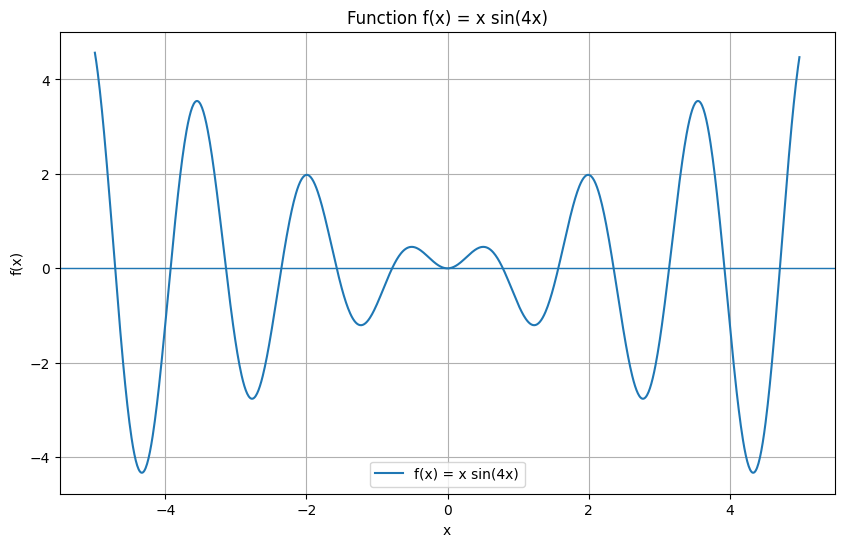

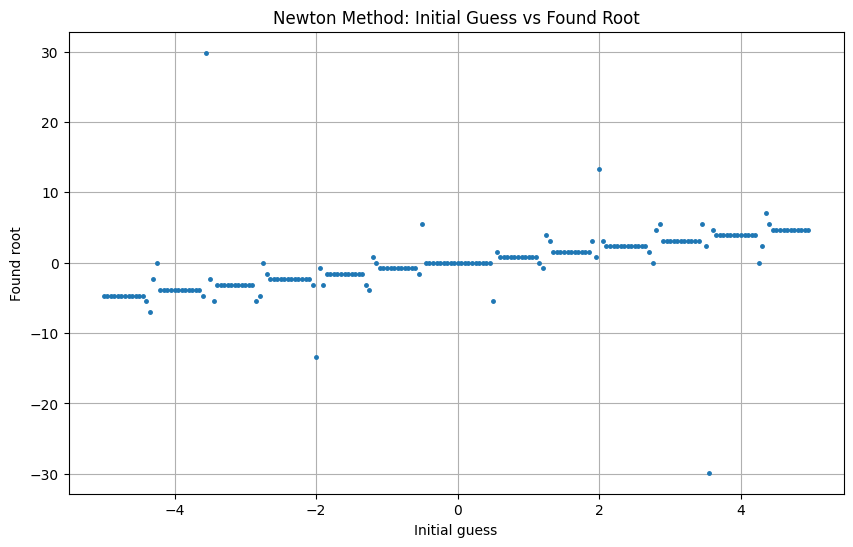

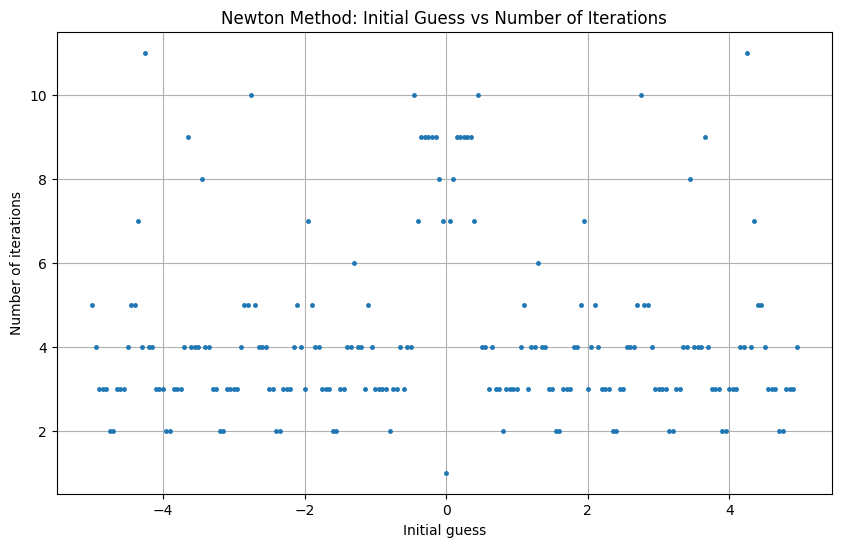


PART 2: Function and Jacobian for the System
-------------------------------------------
F1(x,y,z) = x^2 + y^2 + z^2 - 2
F2(x,y,z) = x^2 + y^2 - 1
F3(x,y,z) = x^2 - y

Jacobian:
[ 2x   2y   2z ]
[ 2x   2y    0 ]
[ 2x   -1    0 ]

PART 3: Multivariate Newton Method
----------------------------------
Start Point                     Solution                          Iterations     Converged
----------------------------------------------------------------------------------------
[0.7, 0.6, 0.8]              [ 0.7861513778,  0.6180339887,  1.0000000000]         4        True
[-0.7, 0.6, 0.8]             [-0.7861513778,  0.6180339887,  1.0000000000]         4        True
[0.7, 0.6, -0.8]             [ 0.7861513778,  0.6180339887, -1.0000000000]         4        True
[-0.7, 0.6, -0.8]            [-0.7861513778,  0.6180339887, -1.0000000000]         4        True

Main solution check:
Solution: [0.78615138 0.61803399 1.        ]
F(solution): [ 2.22044605e-15  0.00000000e+00 -1.11022302e-16]
N

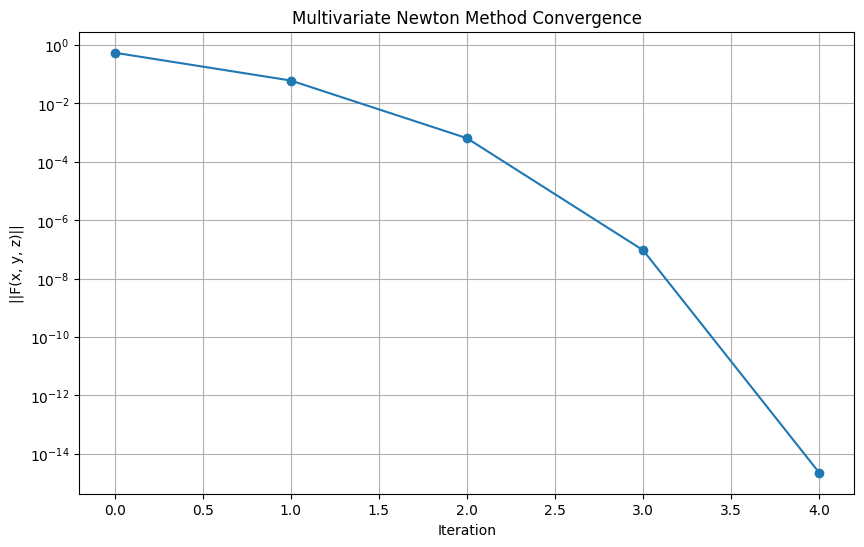

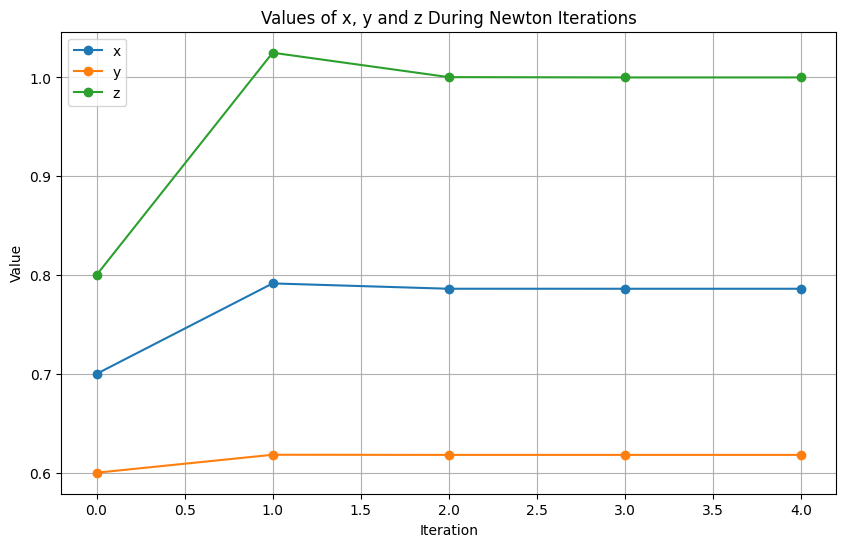


PART 4: Aitken Acceleration for One-Dimensional Case
---------------------------------------------------
Fixed Point Iteration Values:
Iteration  0:  1.000000000000
Iteration  1:  0.540302305868
Iteration  2:  0.857553215846
Iteration  3:  0.654289790498
Iteration  4:  0.793480358743
Iteration  5:  0.701368773623
Iteration  6:  0.763959682901
Iteration  7:  0.722102425027
Iteration  8:  0.750417761764
Iteration  9:  0.731404042423
Iteration 10:  0.744237354901
Iteration 11:  0.735604740436
Iteration 12:  0.741425086610
Iteration 13:  0.737506890513
Iteration 14:  0.740147335568
Iteration 15:  0.738369204122
Iteration 16:  0.739567202212
Iteration 17:  0.738760319874
Iteration 18:  0.739303892397
Iteration 19:  0.738937756715
Iteration 20:  0.739184399771
Iteration 21:  0.739018262427
Iteration 22:  0.739130176530
Iteration 23:  0.739054790747
Iteration 24:  0.739105571927
Iteration 25:  0.739071365299
Iteration 26:  0.739094407379
Iteration 27:  0.739078885995
Iteration 28:  0.7390893

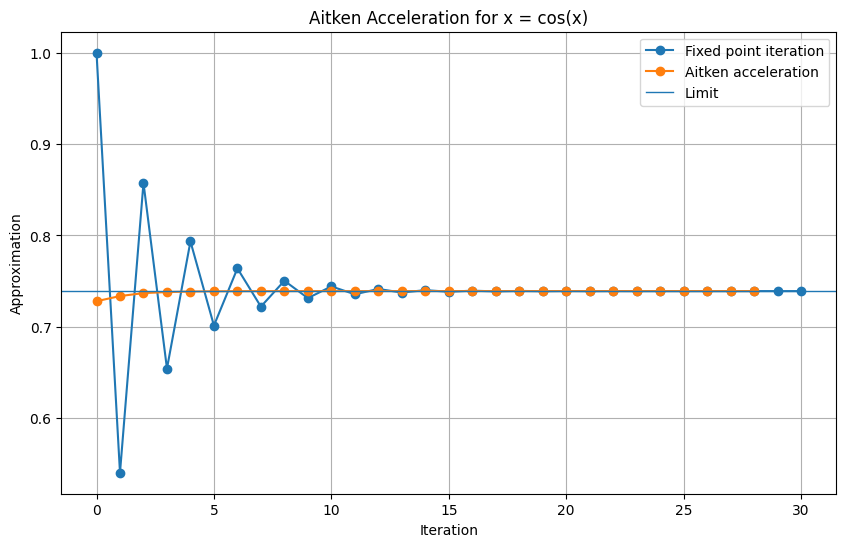

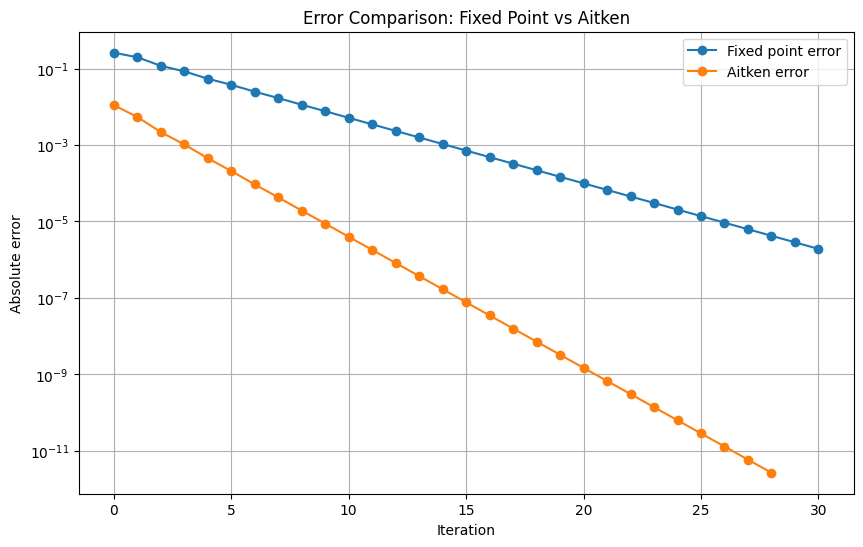

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f_lab4(x):
    return x * np.sin(4 * x)


def df_lab4(x):
    return np.sin(4 * x) + 4 * x * np.cos(4 * x)


def newton_1d(x0, tol_x, tol_f, max_iter):
    x_old = x0

    for iteration in range(1, max_iter + 1):
        derivative = df_lab4(x_old)

        if abs(derivative) < 1e-14:
            return x_old, iteration, False

        x_new = x_old - f_lab4(x_old) / derivative

        if abs(x_new - x_old) <= tol_x:
            return x_new, iteration, True

        if abs(f_lab4(x_new)) <= tol_f:
            return x_new, iteration, True

        x_old = x_new

    return x_old, max_iter, False


def F(v):
    x, y, z = v
    return np.array([
        x**2 + y**2 + z**2 - 2,
        x**2 + y**2 - 1,
        x**2 - y
    ], dtype=float)


def J(v):
    x, y, z = v
    return np.array([
        [2*x, 2*y, 2*z],
        [2*x, 2*y, 0],
        [2*x, -1, 0]
    ], dtype=float)


def newton_multivariate(x0, tol, max_iter):
    x_old = np.array(x0, dtype=float)
    history = [x_old.copy()]
    errors = [np.linalg.norm(F(x_old))]

    for iteration in range(1, max_iter + 1):
        try:
            delta = np.linalg.solve(J(x_old), -F(x_old))
        except np.linalg.LinAlgError:
            return x_old, iteration, False, history, errors

        x_new = x_old + delta

        history.append(x_new.copy())
        errors.append(np.linalg.norm(F(x_new)))

        if np.linalg.norm(delta) <= tol:
            return x_new, iteration, True, history, errors

        if np.linalg.norm(F(x_new)) <= tol:
            return x_new, iteration, True, history, errors

        x_old = x_new

    return x_old, max_iter, False, history, errors


def fixed_point_function(x):
    return np.cos(x)


def fixed_point_iteration(x0, max_iter):
    values = [x0]

    for i in range(max_iter):
        values.append(fixed_point_function(values[-1]))

    return np.array(values)


def aitken_acceleration(values):
    accelerated = []

    for i in range(len(values) - 2):
        denominator = values[i + 2] - 2 * values[i + 1] + values[i]

        if abs(denominator) < 1e-14:
            accelerated.append(np.nan)
        else:
            accelerated_value = values[i] - ((values[i + 1] - values[i]) ** 2) / denominator
            accelerated.append(accelerated_value)

    return np.array(accelerated)


tol_x = 1e-6
tol_f = 1e-6
tol_multi = 1e-10
max_iter_1d = 100
max_iter_multi = 50


print("LAB 5")
print("=====")

print("\nPART 1: Newton Method Dependence on Initial Guess")
print("------------------------------------------------")

initial_guesses = np.arange(-5, 5, 0.05)

roots = []
iterations = []
converged_list = []

for x0 in initial_guesses:
    root, iteration_count, converged = newton_1d(x0, tol_x, tol_f, max_iter_1d)
    roots.append(root)
    iterations.append(iteration_count)
    converged_list.append(converged)

print("Initial Guess     Found Root        Iterations     Converged")
print("------------------------------------------------------------")

for i in range(len(initial_guesses)):
    print(f"{initial_guesses[i]:10.4f}     {roots[i]:10.6f}        {iterations[i]:5d}        {converged_list[i]}")

x_values = np.arange(-5, 5, 0.01)
y_values = f_lab4(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label="f(x) = x sin(4x)")
plt.axhline(0, linewidth=1)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function f(x) = x sin(4x)")
plt.legend()
plt.grid(True)
plt.savefig("lab5_function_graph.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(initial_guesses, roots, ".", markersize=5)
plt.xlabel("Initial guess")
plt.ylabel("Found root")
plt.title("Newton Method: Initial Guess vs Found Root")
plt.grid(True)
plt.savefig("lab5_initial_guess_vs_found_root.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(initial_guesses, iterations, ".", markersize=5)
plt.xlabel("Initial guess")
plt.ylabel("Number of iterations")
plt.title("Newton Method: Initial Guess vs Number of Iterations")
plt.grid(True)
plt.savefig("lab5_initial_guess_vs_iterations.png")
plt.show()


print("\nPART 2: Function and Jacobian for the System")
print("-------------------------------------------")

print("F1(x,y,z) = x^2 + y^2 + z^2 - 2")
print("F2(x,y,z) = x^2 + y^2 - 1")
print("F3(x,y,z) = x^2 - y")

print("\nJacobian:")
print("[ 2x   2y   2z ]")
print("[ 2x   2y    0 ]")
print("[ 2x   -1    0 ]")


print("\nPART 3: Multivariate Newton Method")
print("----------------------------------")

starting_points = [
    [0.7, 0.6, 0.8],
    [-0.7, 0.6, 0.8],
    [0.7, 0.6, -0.8],
    [-0.7, 0.6, -0.8]
]

solutions = []

print("Start Point                     Solution                          Iterations     Converged")
print("----------------------------------------------------------------------------------------")

for start in starting_points:
    solution, iteration_count, converged, history, errors = newton_multivariate(start, tol_multi, max_iter_multi)
    solutions.append((start, solution, iteration_count, converged, history, errors))

    print(f"{str(start):28s} [{solution[0]: .10f}, {solution[1]: .10f}, {solution[2]: .10f}]     {iteration_count:5d}        {converged}")

main_start, main_solution, main_iterations, main_converged, main_history, main_errors = solutions[0]

print("\nMain solution check:")
print("Solution:", main_solution)
print("F(solution):", F(main_solution))
print("Norm of F(solution):", np.linalg.norm(F(main_solution)))
print("Number of iterations:", main_iterations)
print("Converged:", main_converged)

plt.figure(figsize=(10, 6))
plt.plot(range(len(main_errors)), main_errors, marker="o")
plt.xlabel("Iteration")
plt.ylabel("||F(x, y, z)||")
plt.title("Multivariate Newton Method Convergence")
plt.yscale("log")
plt.grid(True)
plt.savefig("lab5_multivariate_newton_convergence.png")
plt.show()

main_history_array = np.array(main_history)

plt.figure(figsize=(10, 6))
plt.plot(range(len(main_history_array)), main_history_array[:, 0], marker="o", label="x")
plt.plot(range(len(main_history_array)), main_history_array[:, 1], marker="o", label="y")
plt.plot(range(len(main_history_array)), main_history_array[:, 2], marker="o", label="z")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Values of x, y and z During Newton Iterations")
plt.legend()
plt.grid(True)
plt.savefig("lab5_xyz_iterations.png")
plt.show()


print("\nPART 4: Aitken Acceleration for One-Dimensional Case")
print("---------------------------------------------------")

x0_aitken = 1.0
fixed_values = fixed_point_iteration(x0_aitken, 30)
aitken_values = aitken_acceleration(fixed_values)

true_value = 0.7390851332151607

fixed_errors = np.abs(fixed_values - true_value)
aitken_errors = np.abs(aitken_values - true_value)

print("Fixed Point Iteration Values:")
for i in range(len(fixed_values)):
    print(f"Iteration {i:2d}: {fixed_values[i]: .12f}")

print("\nAitken Accelerated Values:")
for i in range(len(aitken_values)):
    print(f"Iteration {i:2d}: {aitken_values[i]: .12f}")

plt.figure(figsize=(10, 6))
plt.plot(range(len(fixed_values)), fixed_values, marker="o", label="Fixed point iteration")
plt.plot(range(len(aitken_values)), aitken_values, marker="o", label="Aitken acceleration")
plt.axhline(true_value, linewidth=1, label="Limit")
plt.xlabel("Iteration")
plt.ylabel("Approximation")
plt.title("Aitken Acceleration for x = cos(x)")
plt.legend()
plt.grid(True)
plt.savefig("lab5_aitken_values.png")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(len(fixed_errors)), fixed_errors, marker="o", label="Fixed point error")
plt.plot(range(len(aitken_errors)), aitken_errors, marker="o", label="Aitken error")
plt.xlabel("Iteration")
plt.ylabel("Absolute error")
plt.title("Error Comparison: Fixed Point vs Aitken")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.savefig("lab5_aitken_error_comparison.png")
plt.show()